## Genetic

In [6]:
import numpy as np
from PIL import Image, ImageOps, ImageDraw, ImagePath
from PIL import ImageDraw
from IPython.display import display
import colour

import matplotlib.pyplot as plt

import random
import math

from pandas import DataFrame

In [7]:
# from IPython.display import Image

class Individual:    #Chromosome
    def __init__(self, l, w , num_triangles =None):
        self.l = l  # Width of the image
        self.w = w  # Height of the image
        self.fitness = float('inf')  # Initial fitness is set to infinity
        self.array = None   # Array to store the pixel data of the image
        self.image = None   # Image object
        self.num_triangles = num_triangles
        self.create_random_image_array()     # Create initial random image


    def rand_color(self):
        return "#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)])

    def create_one_color(self):
        self.image = Image.new(mode="RGBA", size=(self.l, self.w), color=self.rand_color())

    def create_random_image_array(self):

        # number of polygons(triangle) to add to image
        # the higher this is the higher stochasticity and potential for detail we have 
        if self.num_triangles is None:
            iterations = random.randint(3, 6)
        else:
            iterations = self.num_triangles


        region = (self.l + self.w)//8

        img = Image.new("RGBA", (self.l, self.w), (0, 0, 0, 255))

        #number of points for each polygon
        for i in range(iterations):
            num_points = 3

            region_x = random.randint(0, self.l)
            region_y = random.randint(0, self.w)

            xy = []
            for j in range(num_points):   #make threshold for points of polygon
                xy.append((random.randint(region_x - region, region_x + region),
                           random.randint(region_y - region, region_y + region)))

            img1 = ImageDraw.Draw(img)
            img1.polygon(xy, fill=self.rand_color())

        self.image = img
        self.array = self.to_array(img)
        

    def add_shape(self):
        iterations = random.randint(1, 1)

        region = random.randint(1,(self.l + self.w)//4)

        img = self.image

        for i in range(iterations):
            num_points = 3

            region_x = random.randint(0, self.l)
            region_y = random.randint(0, self.w)

            xy = []
            for j in range(num_points):
                xy.append((random.randint(region_x - region, region_x + region),
                           random.randint(region_y - region, region_y + region)))

            img1 = ImageDraw.Draw(img)
            img1.polygon(xy, fill=self.rand_color())

        self.image = img
        self.array = self.to_array(img)

    def to_image(self):
        im = Image.fromarray(self.array)
        im.show()

    def to_array(self, image):
        return np.array(image)



    def get_fitness(self, target):
        self.fitness = np.mean(colour.difference.delta_e.delta_E_CIE1976(target, self.array))


# Returns the absolute value of the pixel-by-pixel difference between the two images.
    def get_fitness_euclidean(self, target):
        diff_array = np.subtract(np.array(target), self.array)
        self.fitness = np.mean(np.absolute(diff_array))


In [8]:
class GeneticAlgorithm():
    def __init__(self, image):
        self.target_image = image
        self.l, self.w = self.target_image.size
        self.target_image_array = self.to_array(self.target_image)


    def run_ga(self, pop_size, epochs):
        """
        Main driver of the genetic algorithm

        Keyword arguments:
        pop_size -- the population size for each generation
        epochs -- number of generations to run 

        Returns:
        fittest -- individual with the best fitness from final generation
        """
        # This initializes data as a dictionary to collect details about each epoch
        #  (iteration) for analysis later.
        data = {'epoch':[], 'fitness_estimate':[], 'crossover_used':[], 'pop_gen_used':[], 'im_size':[]}
        
        population = []

        # initialize starting population
        for i in range(pop_size):
            new_indiv = Individual(self.l, self.w)

            new_indiv.get_fitness(self.target_image)

            population.append(new_indiv)  #The list population now contains the first generation of solutions.

        for i in range(epochs):    #generatrion
            new_pop = []

            # estimate for fitness of fittest individual from current epoch's population 
            fittest_estimate = float('inf')

            # populate our new population
            while len(new_pop) < len(population):
                # select parents for crossover
                parent_one = self.tournament_select(population)
                parent_two = self.tournament_select(population)

                fittest_estimate = min(parent_one.fitness, parent_two.fitness, fittest_estimate)

                # probabilistically determine how child of both parents is created 
                rand = random.uniform(0, 1)
                        
                if rand < 0.3:
                    child = self.crossover(parent_one, parent_two)

                    while child == None:
                        parent_one = self.tournament_select(population)
                        parent_two = self.tournament_select(population)

                        child = self.crossover(parent_one, parent_two)

                elif rand <= 0.9:
                    child = self.crossover_2(parent_one, parent_two, 0.5)

                    while child == None:
                        parent_one = self.tournament_select(population)
                        parent_two = self.tournament_select(population)

                        child = self.crossover_2(parent_one, parent_two, 0.5)
                
                else:
                    child = self.mutate(parent_one)

                    while child == None:
                        parent_one = self.tournament_select(population)
                        child = self.mutate(parent_one)

                # add child to new population
                new_pop.append(child)

            # set population = new_pop
            population = new_pop
            
            # fitness data recording 
            if i % 100 == 0 or i == epochs - 1:         #100100
                data['epoch'].append(i)
                data['fitness_estimate'].append(fittest_estimate)
                data['crossover_used'].append("crossover_1")
                data['pop_gen_used'].append("random_image_array_1")
                data['im_size'].append("(" + str(self.w) + "," + str(self.l) + ")")
            
            # save images on interval to see progress  
            # if i % 100 == 0 or i == epochs - 1:
            if i % 100 == 0 or i == epochs - 1:           #100100

                print("Most fit individual in epoch " + str(i) +
                    " has fitness: " + str(fittest_estimate))
                
                population.sort(key=lambda ind: ind.fitness)
                fittest = population[0]

                fittest.image.save("GenImg/fittest_" + str(i)+".png")
                
                data_df = DataFrame(data)
    
                data_df.to_csv("./GenImg/data_cross.csv")

        # save collected data to csv 
        data_df = DataFrame(data)
        data_df.to_csv("./GenImg/data_cross.csv")

        # fittest individual of the final population 
        population.sort(key=lambda ind: ind.fitness)
        fittest = population[0]

        return fittest


    def tournament_select(self, population, tournament_size=6):
        """
        Selects the most fit individual from a randomly sampled subset of the population

        Keyword arguments:
        population -- current generation's population
        tournament_size -- number of individuals randomly sampled to participate

        Returns:
        winner -- individual with the best fitness out of the tournament_size participants
        """

        # randomly sample participants
        indices = np.random.choice(len(population), tournament_size)
        random_subset = [population[i] for i in indices]

        winner = None

        # find individual with best fitness 
        for i in random_subset:
            if (winner == None):
                winner = i
            elif i.fitness < winner.fitness:
                winner = i

        return winner


    def crossover(self, ind1, ind2):
        """
        Performs 'blend' crossover given two parents and creates a child \
            It takes a weighted average of each parent and overlays them

        Keyword arguments:
        ind1 -- parent number 1
        ind2 -- parent number 2

        Returns:
        child or None -- child of the two parents if it is more fit than both parents
        """
        
        child = Individual(self.l, self.w)

        # random float between 0 and 1 
        blend_alpha = random.random()

        # if blend_alpha is 0.0, a copy of the first image is returned. 
        # If blend_alpha is 1.0, a copy of the second image is returned.
        # use a random blend_alpha \in (0,1) 
        child_image = Image.blend(ind1.image, ind2.image, blend_alpha)
        child.image = child_image
        child.array = np.array(child_image)
        child.get_fitness(self.target_image)

        # elitism 
        if child.fitness == min(ind1.fitness, ind2.fitness, child.fitness):
            return child

        return None

    
    def crossover_2(self, ind1, ind2, horizontal_prob = 0.5):
        """
        Performs 'crossover point' crossover given two parents and creates a child \
            Randomly selects the crossover point to be either a row or column \
            Everything up until the crossover point is from parent 1, everything after is parent 2

        Keyword arguments:
        ind1 -- parent number 1
        ind2 -- parent number 2

        Returns:
        child or None -- child of the two parents if it is more fit than both parents
        """

        rand = random.random()

        # perform horizontal crossover point 
        if rand <= horizontal_prob:

            split_point = random.randint(1, self.w)
            
            first = np.ones((split_point, self.l))
            first = np.vstack((first, np.zeros((self.w-split_point, self.l))))

        # perform vertical crossover point 
        else:
            split_point = random.randint(1, self.l)
        
            first = np.ones((self.w, split_point))
            first = np.hstack((first, np.zeros((self.w, self.l-split_point))))
            
        second = 1 - first

        # Creates the 4 dimensional versions to perform the mutliplying across all color channels 
        first = np.dstack([first,first,first,first])
        second = np.dstack([second,second,second,second])

        # Multiply parent1 with first and multiply parent2 with second. Then simplay add them element wise and it should produce the crossover child.

        half_chromo_1 = np.multiply(first, ind1.array)
        half_chromo_2 = np.multiply(second, ind2.array)
        
        child_array = np.add(half_chromo_1, half_chromo_2)
        
        child = Individual(self.l, self.w)
        
        child.image = Image.fromarray(child_array.astype(np.uint8))
        child.array = child_array.astype(np.uint8)
        
        child.get_fitness(self.target_image)

        # elitism 
        if child.fitness == min(ind1.fitness, ind2.fitness, child.fitness):
            return child

        return None


    def crossover_3(self, ind1, ind2):
        """
        Performs 'pixel-wise' crossover given two parents and creates a child \
            Each pixel is randomly selected from either parent 1 or parent 2

        Keyword arguments:
        ind1 -- parent number 1
        ind2 -- parent number 2

        Returns:
        child or None -- child of the two parents if it is more fit than both parents
        """
        first = np.random.randint(2, size=(self.w, self.l, 4))
        
        second = 1 - first
        
        half_chromo_1 = np.multiply(first, ind1.array)
        
        half_chromo_2 = np.multiply(second, ind2.array)
        
        child_array = np.add(half_chromo_1, half_chromo_2)
        
        child = Individual(self.l, self.w)
        
        child.image = Image.fromarray(child_array.astype(np.uint8))
        child.array = child_array.astype(np.uint8)
        
        child.get_fitness(self.target_image)
        
        return child


    def mutate(self, ind):
        """
        Mutates an individual by superimposing a random number of randomly colored shapes(triangle)

        Keyword arguments:
        ind -- individual to be mutated

        Returns:
        child -- the individual post mutation
        """

        iterations = random.randint(1, 3)
        region = random.randint(1,(self.l + self.w)//4)

        img = ind.image

        for i in range(iterations):
            num_points = 3
            region_x = random.randint(0, self.l)
            region_y = random.randint(0, self.w)

            xy = []
            for j in range(num_points):
                xy.append((random.randint(region_x - region, region_x + region),
                           random.randint(region_y - region, region_y + region)))

            img1 = ImageDraw.Draw(img)
            img1.polygon(xy, fill=ind.rand_color())

        child = Individual(ind.l, ind.w)
        child.image = img
        child.array = child.to_array(child.image)
        child.get_fitness(self.target_image)

        return child 

        
    def mutate_2(self, ind):
        """
        Mutates an individual by selecting a random subset of pixels and altering their RGB values

        Keyword arguments:
        ind -- individual to be mutated

        Returns:
        child -- the individual post mutation
        """
        
        num_pix = 40
        
        for i in range(num_pix):
            x = random.randint(0, self.l-1)
            y = random.randint(0, self.w-1)
            z = random.randint(0, 3)
            
            ind.array[x][y][z] = ind.array[x][y][z] + random.randint(-10,10)
                
        ind.image = self.to_image(ind.array)
        ind.get_fitness(self.target_image)

    def to_image(self, array):
        return Image.fromarray(array)

    def to_array(self, image):
        return np.array(image)

In [9]:
def resize(image,max_size):
    new_width = int((max_size/max(image.size[0],image.size[1]))* image.size[0])
    new_height = int((max_size/max(image.size[0],image.size[1]))* image.size[1])
    image = image.resize((new_width,new_height), resample=Image.Resampling.LANCZOS)  
    return image

Most fit individual in epoch 0 has fitness: 263.646615719
Most fit individual in epoch 100 has fitness: 76.2296264327
Most fit individual in epoch 200 has fitness: 61.1170362755
Most fit individual in epoch 300 has fitness: 54.6836875317
Most fit individual in epoch 400 has fitness: 48.7324704441
Most fit individual in epoch 500 has fitness: 46.8344310843
Most fit individual in epoch 600 has fitness: 45.1374986299
Most fit individual in epoch 700 has fitness: 43.1975094345
Most fit individual in epoch 800 has fitness: 41.63215476
Most fit individual in epoch 900 has fitness: 39.6424975087
Most fit individual in epoch 1000 has fitness: 39.1649841445
Most fit individual in epoch 1100 has fitness: 38.2023041739
Most fit individual in epoch 1200 has fitness: 37.8248015966
Most fit individual in epoch 1300 has fitness: 37.1795212417
Most fit individual in epoch 1400 has fitness: 36.6295466775
Most fit individual in epoch 1500 has fitness: 36.4978490736
Most fit individual in epoch 1600 has 

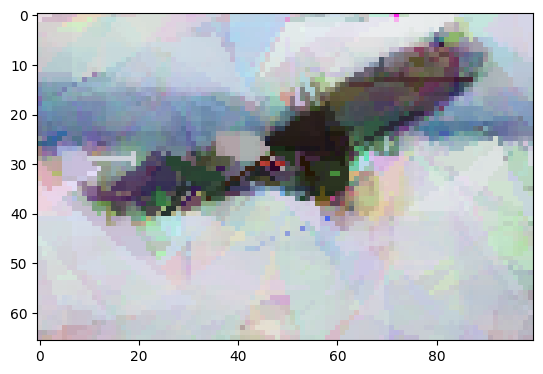

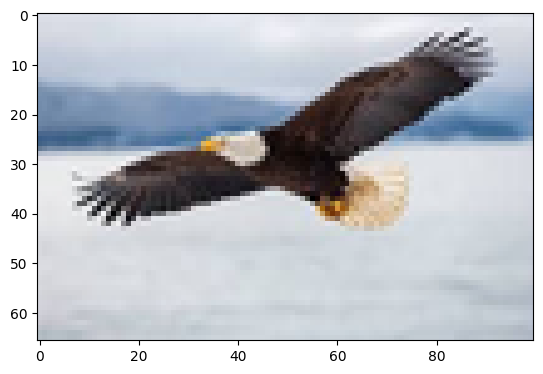

In [10]:
target_image_path = "./target_images/eagle.png"
image = Image.open(target_image_path)

image = resize(image,100)

ga = GeneticAlgorithm(image)

population_size=100
echos=5000

fittest = ga.run_ga(population_size , echos) #population size and number of generation
plt.imshow(fittest.image)
plt.show()

image = resize(image,100)
plt.imshow(image)
plt.show()

CROSSOVER

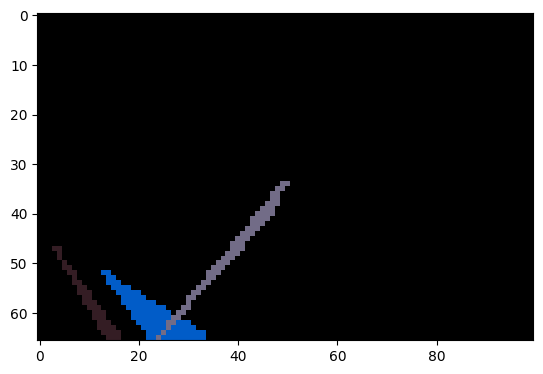

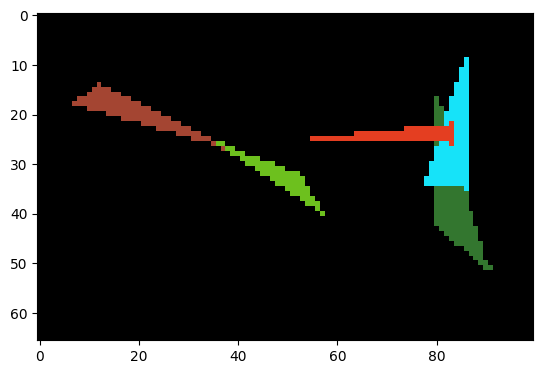

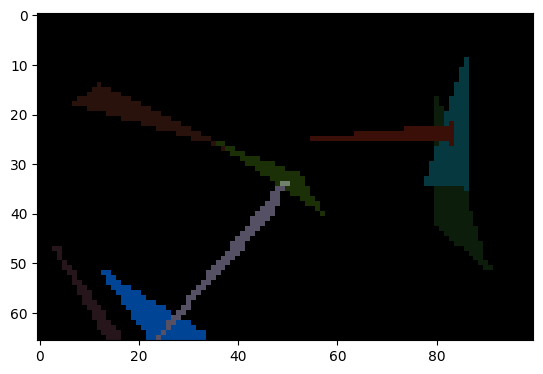

In [11]:
ind1 = Individual(100, 66)
plt.imshow(ind1.image)
plt.show()
ind2 = Individual(100, 66)
plt.imshow(ind2.image)
plt.show()
ind3 = ga.crossover(ind1, ind2)
plt.imshow(ind3.image)
plt.show()

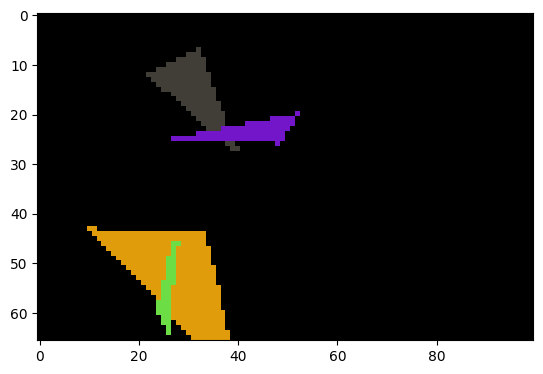

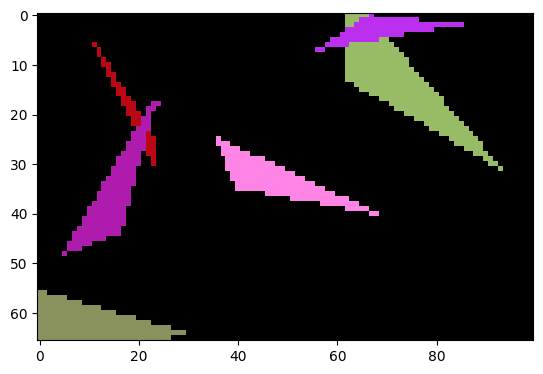

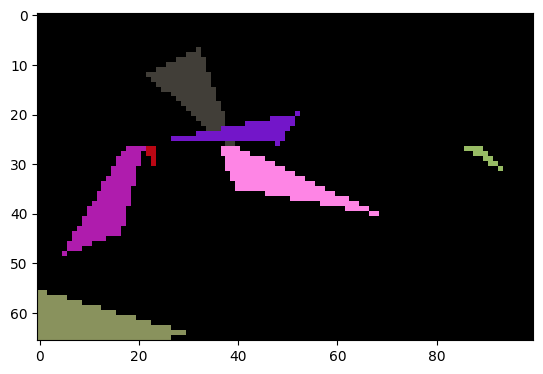

In [12]:
ind1 = Individual(100, 66)
plt.imshow(ind1.image)
plt.show()
ind2 = Individual(100, 66)
plt.imshow(ind2.image)
plt.show()
ind3 = ga.crossover_2(ind1, ind2)
plt.imshow(ind3.image)
plt.show()

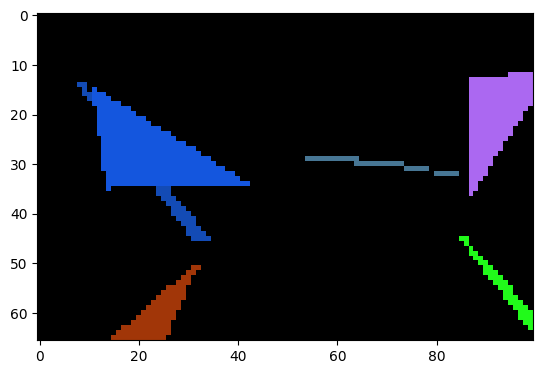

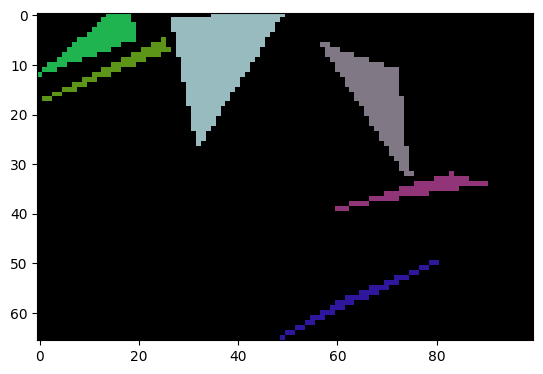

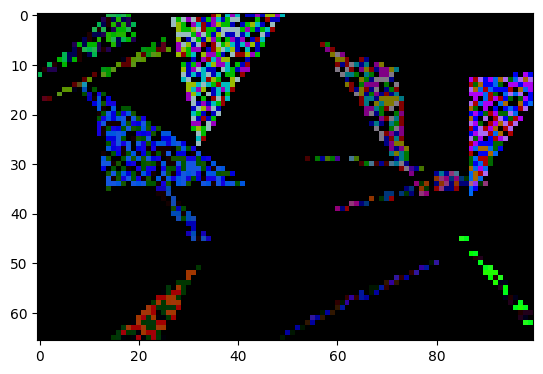

In [13]:
ind1 = Individual(100, 66)
plt.imshow(ind1.image)
plt.show()
ind2 = Individual(100, 66)
plt.imshow(ind2.image)
plt.show()
ind3 = ga.crossover_3(ind1, ind2)
plt.imshow(ind3.image)
plt.show()